# Day 1 Companion Notebook: RNN Theory & Vanishing Gradients

**COMP 395 – Deep Learning**

This notebook accompanies the Day 1 lecture slides. You'll run these activities when prompted during the lecture.

**Prerequisites:** NumPy, Matplotlib (should already be in your environment)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

# Make plots look nice
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['font.size'] = 12


---
## Section 1: Watching the Hidden State Evolve

A vanilla RNN updates its hidden state at each time step:

$$\mathbf{h}_t = \tanh(\mathbf{W}_{hh} \mathbf{h}_{t-1} + \mathbf{W}_{xh} \mathbf{x}_t + \mathbf{b})$$

Let's build a simple RNN cell from scratch and watch what happens to the hidden state as we process a long sequence.


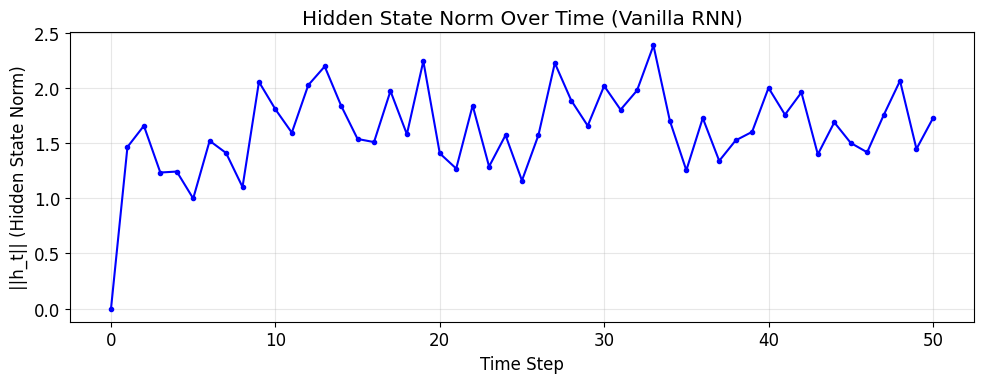

In [2]:
# A simple RNN cell in pure NumPy
class SimpleRNNCell:
    def __init__(self, input_size, hidden_size):
        # Initialize weights with small random values
        scale = 0.1
        self.W_xh = np.random.randn(hidden_size, input_size) * scale
        self.W_hh = np.random.randn(hidden_size, hidden_size) * scale
        self.b_h = np.zeros(hidden_size)
        self.hidden_size = hidden_size

    def forward(self, x_t, h_prev):
        """One step of the RNN."""
        z = self.W_hh @ h_prev + self.W_xh @ x_t + self.b_h
        h_t = np.tanh(z)
        return h_t

# Create an RNN cell
input_size = 8
hidden_size = 32
rnn = SimpleRNNCell(input_size, hidden_size)

# Process a sequence of 50 random inputs
seq_length = 50
inputs = [np.random.randn(input_size) for _ in range(seq_length)]

# Track hidden state norms
h = np.zeros(hidden_size)
norms = [np.linalg.norm(h)]

for x_t in inputs:
    h = rnn.forward(x_t, h)
    norms.append(np.linalg.norm(h))

# Plot
plt.plot(norms, 'b-o', markersize=3)
plt.xlabel('Time Step')
plt.ylabel('||h_t|| (Hidden State Norm)')
plt.title('Hidden State Norm Over Time (Vanilla RNN)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### ✏️ Questions (discuss with your partner)

1. Does the hidden state norm stabilize, grow, or shrink? Why?
2. What role does `tanh` play in keeping the values bounded?
3. What happens if we change the weight scale from `0.1` to `1.0`? Try it!


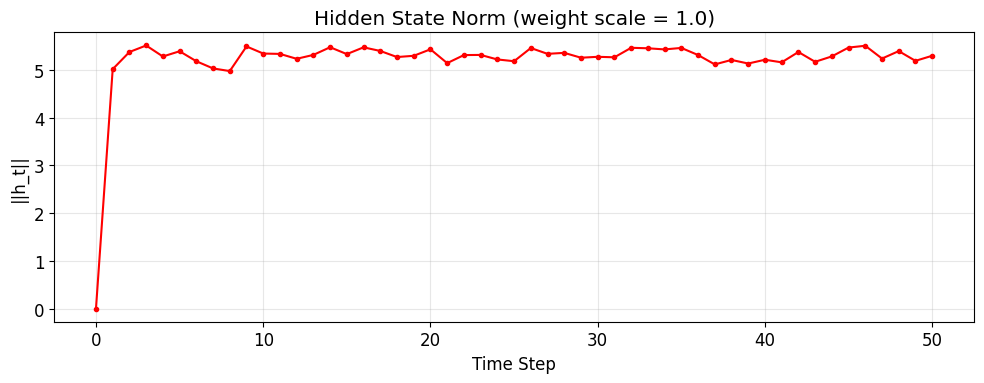

In [3]:
# YOUR EXPERIMENT: Change the scale and re-run
# Try scale = 1.0, then scale = 2.0. What changes?

scale = 1.0  # <-- Modify this
rnn_exp = SimpleRNNCell(input_size, hidden_size)
rnn_exp.W_xh = np.random.randn(hidden_size, input_size) * scale
rnn_exp.W_hh = np.random.randn(hidden_size, hidden_size) * scale

h = np.zeros(hidden_size)
norms_exp = [np.linalg.norm(h)]
for x_t in inputs:
    h = rnn_exp.forward(x_t, h)
    norms_exp.append(np.linalg.norm(h))

plt.plot(norms_exp, 'r-o', markersize=3)
plt.xlabel('Time Step')
plt.ylabel('||h_t||')
plt.title(f'Hidden State Norm (weight scale = {scale})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Section 2: The Vanishing/Exploding Gradient Problem — Visualized

During backpropagation through time, the gradient flowing back from time step $T$ to time step $0$ involves a product:

$$\prod_{t=1}^{T} \frac{\partial \mathbf{h}_t}{\partial \mathbf{h}_{t-1}} \approx \prod_{t=1}^{T} \mathbf{W}_{hh}$$

(simplified — ignoring the tanh derivative for intuition)

This means we're essentially computing $\mathbf{W}_{hh}^T$. Let's see what happens.

### 🔮 Before running the next cell: PREDICT what the three plots will look like!


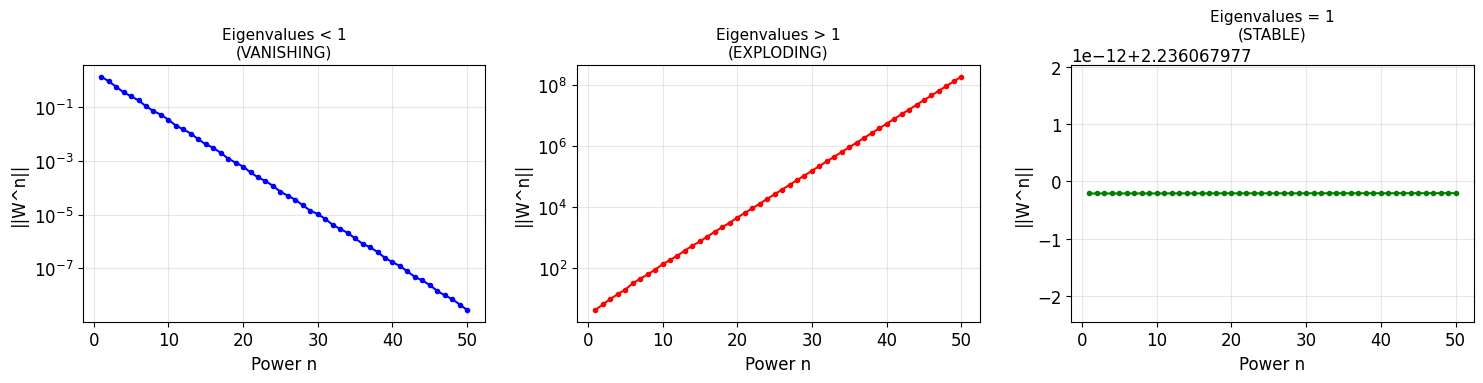

Vanishing — max |eigenvalue|: 0.667
Exploding — max |eigenvalue|: 1.429
Stable    — max |eigenvalue|: 1.000


In [4]:
def compute_matrix_power_norms(W, max_power=50):
    """Compute ||W^n|| for n = 1 to max_power."""
    norms = []
    result = np.eye(W.shape[0])
    for n in range(max_power):
        result = result @ W
        norms.append(np.linalg.norm(result))
    return norms

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Case 1: Eigenvalues < 1 (VANISHING)
W_vanish = np.random.randn(5, 5)
# Scale so max eigenvalue < 1
W_vanish = W_vanish / (np.max(np.abs(np.linalg.eigvals(W_vanish))) * 1.5)
norms_v = compute_matrix_power_norms(W_vanish, 50)
axes[0].plot(range(1, 51), norms_v, 'b-o', markersize=3)
axes[0].set_title('Eigenvalues < 1\n(VANISHING)', fontsize=11)
axes[0].set_xlabel('Power n')
axes[0].set_ylabel('||W^n||')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Case 2: Eigenvalues > 1 (EXPLODING)
W_explode = np.random.randn(5, 5)
W_explode = W_explode / (np.max(np.abs(np.linalg.eigvals(W_explode))) * 0.7)
norms_e = compute_matrix_power_norms(W_explode, 50)
axes[1].plot(range(1, 51), norms_e, 'r-o', markersize=3)
axes[1].set_title('Eigenvalues > 1\n(EXPLODING)', fontsize=11)
axes[1].set_xlabel('Power n')
axes[1].set_ylabel('||W^n||')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

# Case 3: Orthogonal matrix (eigenvalues = 1) (STABLE)
U, _, Vt = np.linalg.svd(np.random.randn(5, 5))
W_stable = U @ Vt  # orthogonal matrix
norms_s = compute_matrix_power_norms(W_stable, 50)
axes[2].plot(range(1, 51), norms_s, 'g-o', markersize=3)
axes[2].set_title('Eigenvalues = 1\n(STABLE)', fontsize=11)
axes[2].set_xlabel('Power n')
axes[2].set_ylabel('||W^n||')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print eigenvalue magnitudes for reference
print("Vanishing — max |eigenvalue|:", f"{np.max(np.abs(np.linalg.eigvals(W_vanish))):.3f}")
print("Exploding — max |eigenvalue|:", f"{np.max(np.abs(np.linalg.eigvals(W_explode))):.3f}")
print("Stable    — max |eigenvalue|:", f"{np.max(np.abs(np.linalg.eigvals(W_stable))):.3f}")


### ✏️ Reflection

1. On the vanishing plot (left), the gradient reaching time step 0 from time step 50 is essentially **zero**. What does this mean for learning?
2. On the exploding plot (middle), the gradient becomes astronomically large. What would happen to weight updates?
3. The stable plot (right) uses an **orthogonal matrix**. Why does this preserve gradient magnitude? (Hint: what do orthogonal matrices do to vector lengths?)

---


## Section 3 (Bonus): Gradient Clipping in Action

Gradient clipping is the simplest fix for **exploding** gradients. The idea: if the gradient norm exceeds a threshold, rescale it.


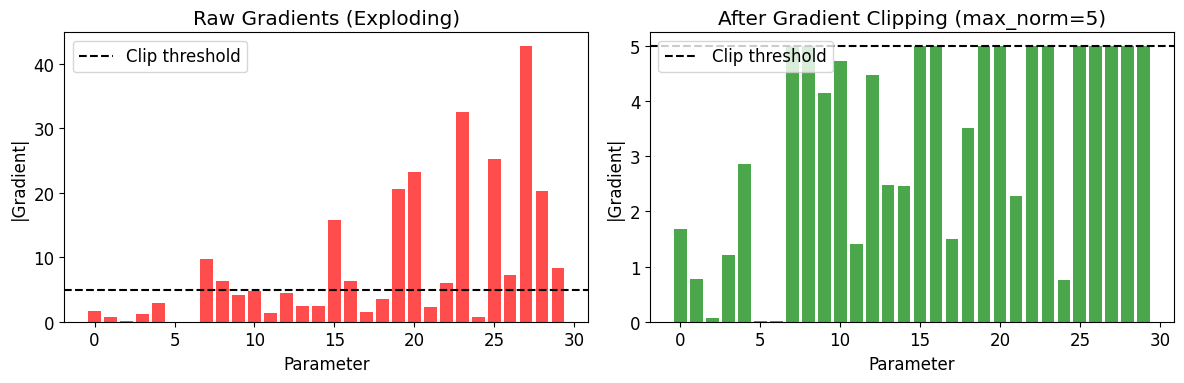

In [5]:
def gradient_clip(gradient, max_norm):
    """Clip gradient if its norm exceeds max_norm."""
    norm = np.linalg.norm(gradient)
    if norm > max_norm:
        gradient = max_norm * gradient / norm
    return gradient

# Simulate a sequence of gradients (some exploding)
np.random.seed(7)
raw_gradients = np.random.randn(30) * np.linspace(1, 20, 30)  # increasingly large
clipped_gradients = [gradient_clip(np.array([g]), max_norm=5.0)[0] for g in raw_gradients]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(30), np.abs(raw_gradients), color='red', alpha=0.7)
axes[0].axhline(y=5.0, color='black', linestyle='--', label='Clip threshold')
axes[0].set_title('Raw Gradients (Exploding)')
axes[0].set_xlabel('Parameter')
axes[0].set_ylabel('|Gradient|')
axes[0].legend()

axes[1].bar(range(30), np.abs(clipped_gradients), color='green', alpha=0.7)
axes[1].axhline(y=5.0, color='black', linestyle='--', label='Clip threshold')
axes[1].set_title('After Gradient Clipping (max_norm=5)')
axes[1].set_xlabel('Parameter')
axes[1].set_ylabel('|Gradient|')
axes[1].legend()

plt.tight_layout()
plt.show()



---

## What's Next?

**Tomorrow (Day 2):** You'll use **PyTorch** to:
1. Implement a vanilla RNN forward pass **from scratch** in NumPy
2. Train an RNN on a **text classification** task (sentiment analysis)
3. Use **gradient hooks** to measure gradient magnitudes at each layer
4. **See** the vanishing gradient problem in a real training loop
5. Swap in an **LSTM** and watch the gradients stabilize
